In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os 
from scipy.integrate import trapezoid
from numpy.typing import ArrayLike
from brokenaxes import brokenaxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.signal import convolve, fftconvolve
from scipy.interpolate import PchipInterpolator, interp1d

import matplotlib.patches as patches




In [6]:
def dB_to_linear(RIN_dB: ArrayLike):

    return 10**(RIN_dB/10)


def linear_to_dB(RIN_lin: ArrayLike):
    
    return 10*np.log10(RIN_lin)

def integrated_RIN(freqs: ArrayLike, RIN_dB: ArrayLike):

    RIN_lin = dB_to_linear(RIN_dB)

    int_RIN_lin = trapezoid(x=freqs,y=RIN_lin)

    return int_RIN_lin


def SHG_RIN_spec(RIN_pump: ArrayLike): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in dB/Hz

    RIN_lin = dB_to_linear(RIN_pump)

    SHG_RIN_lin = 4*RIN_lin + 2* convolve(RIN_lin,RIN_lin)

    return linear_to_dB(SHG_RIN_lin)

def approx_SHG_RIN_spec(RIN_pump: ArrayLike): #Approximate SHG RIN. Input and output RIN is in dB/Hz

    RIN_lin = dB_to_linear(RIN_pump)

    SHG_RIN_lin = 4*RIN_lin

    return linear_to_dB(SHG_RIN_lin)


def SFG_RIN_spec(RIN_pump_1: ArrayLike, RIN_pump_2: ArrayLike): #reduced RIN (Isserlis' theorem applied) for completely uncorrelated pumps. Input and output RIN is in dB/Hz

    RIN_lin_1 = dB_to_linear(RIN_pump_1)
    RIN_lin_2 = dB_to_linear(RIN_pump_2)

    SFG_RIN_lin = RIN_lin_1 + RIN_lin_2 + convolve(RIN_lin_1,RIN_lin_2)

    return linear_to_dB(SFG_RIN_lin)


def cascaded_RIN_spec(freqs: ArrayLike, RIN_pump: ArrayLike): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in dB/Hz

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    cascaded_RIN_lin = RIN_lin*(9 + 18*RIN_int + 9*RIN_int**2) + 18* convolve(RIN_lin,RIN_lin) + 6* convolve(convolve(RIN_lin,RIN_lin),RIN_lin)

    return linear_to_dB(cascaded_RIN_lin)


def THG_RIN_spec(freqs: ArrayLike, RIN_pump: ArrayLike): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in dB/Hz

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    cascaded_RIN_lin = RIN_lin*(9 + 18*RIN_int + 9*RIN_int**2) + 18* convolve(RIN_lin,RIN_lin) + 6* convolve(convolve(RIN_lin,RIN_lin),RIN_lin)


    return linear_to_dB(cascaded_RIN_lin)

def approx_THG_RIN_spec(RIN_pump: ArrayLike):
    
    RIN_THG = linear_to_dB(dB_to_linear(RIN_pump)*9)

    return RIN_THG


def THG_RIN_spec_var(RIN_pump: ArrayLike, RIN_int_dB: float): #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in dB/Hz

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = dB_to_linear(RIN_int_dB)

    # RIN_int = var # variance/1mW^2 such that we get the integrated RIN value 

    cascaded_RIN_lin = RIN_lin*(9 + 18*RIN_int + 9*RIN_int**2) + 18* convolve(RIN_lin,RIN_lin) + 6* convolve(convolve(RIN_lin,RIN_lin),RIN_lin)


    return linear_to_dB(cascaded_RIN_lin)


### Terms comparison

def RIN_squared(RIN_pump: ArrayLike):

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_sq = convolve(RIN_lin,RIN_lin)

    return linear_to_dB(RIN_sq)

    
def RIN_tripled(RIN_pump: ArrayLike):

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_tri = convolve(convolve(RIN_lin,RIN_lin),RIN_lin)

    return linear_to_dB(RIN_tri)
    

def variance_offset(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return linear_to_dB(RIN_int)

    
def variance_squared_offset(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return linear_to_dB(RIN_int**2)


def RIN_variance(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return linear_to_dB(RIN_lin*RIN_int)
    

def RIN_variance_squared(freqs: ArrayLike, RIN_pump: ArrayLike):

    RIN_lin = dB_to_linear(RIN_pump)

    RIN_int = trapezoid(x=freqs,y=RIN_lin)

    return linear_to_dB(RIN_lin*RIN_int**2)


In [7]:
def gaussian_peak (freqs,amplitude,center,standard_deviation):

    return amplitude/(standard_deviation*np.sqrt(2*np.pi))*np.exp(-(freqs-center)**2/(2*standard_deviation**2))

def model_RIN_spec(freqs, RIN_offset = 10**(-105/10), RIN_offset_high_freq = 10**(-141/10), decay_freq=5.7e5, decay_factor = 1.73e-6, decay_expo =6,  first_rel_osc = [1e3,6e3,8e-7,3e3,0.5e3], second_rel_osc=[1e5,6e5,1.6e-5,4.5e5,0.4e5], first_high_freq=[9.4e5,9.6e5,3e-8,9.5e5,0.4e4], second_high_freq=[1.86e6,1.91e6,8e-10,1.88e6,5e3]):


    freqs_3khz_min = first_rel_osc[0]
    freqs_3khz_max = first_rel_osc[1]
    amp_3khz = first_rel_osc[2]
    center_3khz = first_rel_osc[3]
    std_3khz = first_rel_osc[4]

    freqs_500khz_min = second_rel_osc[0]
    freqs_500khz_max = second_rel_osc[1]
    amp_500khz = second_rel_osc[2]
    center_500khz = second_rel_osc[3]
    std_500khz = second_rel_osc[4]

    freqs_900khz_min = first_high_freq[0]
    freqs_900khz_max = first_high_freq[1]
    amp_900khz = first_high_freq[2]
    center_900khz = first_high_freq[3]
    std_900khz = first_high_freq[4]

    freqs_1800khz_min = second_high_freq[0]
    freqs_1800khz_max = second_high_freq[1]
    amp_1800khz = second_high_freq[2]
    center_1800khz = second_high_freq[3]
    std_1800khz = second_high_freq[4]



    freqs_decay = freqs[(freqs > decay_freq)]
    
    rin_spectrum = np.zeros_like(freqs) + RIN_offset

    rin_spectrum[(freqs > decay_freq)] = RIN_offset/(freqs_decay*decay_factor)**decay_expo + RIN_offset_high_freq

    
    freqs_3khz =  freqs[(freqs >= freqs_3khz_min) & (freqs <= freqs_3khz_max)]
    freqs_500khz =  freqs[(freqs >= freqs_500khz_min) & (freqs <= freqs_500khz_max)]
    freqs_900khz = freqs[(freqs >= freqs_900khz_min) & (freqs <= freqs_900khz_max)]
    freqs_1800khz = freqs[(freqs >= freqs_1800khz_min) & (freqs <= freqs_1800khz_max)]


    rin_spectrum[(freqs >= freqs_3khz_min) & (freqs <= freqs_3khz_max)] += gaussian_peak(freqs_3khz,amp_3khz,center_3khz,std_3khz)

    rin_spectrum[(freqs >= freqs_500khz_min) & (freqs <= freqs_500khz_max)] += gaussian_peak(freqs_500khz,amp_500khz,center_500khz,std_500khz)

    rin_spectrum[(freqs >= freqs_900khz_min) & (freqs <= freqs_900khz_max)] += gaussian_peak(freqs_900khz,amp_900khz,center_900khz,std_900khz)

    rin_spectrum[(freqs >= freqs_900khz_min) & (freqs <= freqs_900khz_max)] += gaussian_peak(freqs_900khz,amp_900khz,center_900khz,std_900khz)
    
    rin_spectrum[(freqs >= freqs_1800khz_min) & (freqs <= freqs_1800khz_max)] += gaussian_peak(freqs_1800khz,amp_1800khz,center_1800khz,std_1800khz)

    return rin_spectrum


In [8]:
data_path = r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Frequency conversion RIN and FN\Pertoldi\RIN data" #"C:\Users\au617810\Downloads\Frequency conversion RIN and FN\RIN data"


files = os.listdir(data_path)

for file in files:
    if '2095' in file:
        pump_path = data_path + '\\' + file 

    if 'SHG' in file:
        SHG_path = data_path + '\\' + file 
        
    if 'THG' in file:
        THG_path = data_path + '\\' + file

    if 'SFG' in file:
        SFG_path = data_path + '\\' + file
    
    if '1081' in file:
        SFG_pump1_path = data_path + '\\' + file

    if '1970' in file:
        SFG_pump2_path = data_path + '\\' + file


print(
'''The data itself is not the raw trace, but it includes a spline fit. \nAlso, to plot the log-spaced data as it is in the paper, I have interpolated it as follows: 

frequencies = np.logspace(np.log10(0.003), np.log10(3e7), int(1e5))

interp_func = interpolate.interp1d(RINFreq, RIN, kind='linear', fill_value='extrapolate')

RIN_new = interp_func(frequencies)

I found a note specifying the PD power for the 2095 nm and THG 698 nm measurements, \nthe rest of the data is probably in the same range.''')

The data itself is not the raw trace, but it includes a spline fit. 
Also, to plot the log-spaced data as it is in the paper, I have interpolated it as follows: 

frequencies = np.logspace(np.log10(0.003), np.log10(3e7), int(1e5))

interp_func = interpolate.interp1d(RINFreq, RIN, kind='linear', fill_value='extrapolate')

RIN_new = interp_func(frequencies)

I found a note specifying the PD power for the 2095 nm and THG 698 nm measurements, 
the rest of the data is probably in the same range.


In [9]:
pump_data = np.loadtxt(pump_path)

SHG_data = np.loadtxt(SHG_path)

THG_data = np.loadtxt(THG_path)

SFG_data = np.loadtxt(SFG_path)

SFG_pump1_data = np.loadtxt(SFG_pump1_path)

SFG_pump2_data = np.loadtxt(SFG_pump2_path)


In [10]:
#Check that spline keeps peaks well-resolved:

f_full = pump_data[:,0]
S_full = pump_data[:,1]

freq_check = [(f_full>=1e3) & (f_full<=3e7)][0]


f = f_full[freq_check]
S = S_full[freq_check]

# spacing
df_forward  = f[1:] - f[:-1]
df_backward = f[1:] - f[:-1]

# first derivative at interior points
dS_df = (S[1:] - S[:-1]) / (f[1:] - f[:-1])     # length N-2

# second derivative at interior points
term1 = (S[2:] - S[1:-1]) / (f[2:] - f[1:-1])
term2 = (S[1:-1] - S[:-2]) / (f[1:-1] - f[:-2])

d2S_df2 = (term1 - term2) / (0.5 * (f[2:] - f[:-2]))  # length N-2

max_curv = np.max(np.abs(d2S_df2))

indices= np.where(np.abs(d2S_df2)>0.1*max_curv)

d2S_df2[indices]

array([-0.00194987, -0.00353879, -0.00366792, -0.00517694, -0.00087997,
       -0.00080182, -0.00106334, -0.00203252,  0.00097306,  0.00169549,
        0.00324931, -0.00129915, -0.00150589, -0.00412623, -0.00337088,
       -0.00117814, -0.00228427, -0.00093782,  0.00196691,  0.0046118 ,
        0.00752813,  0.00118343,  0.00263472,  0.00179097, -0.00141126,
       -0.00433522, -0.00173917, -0.00374827, -0.00264928,  0.00095123,
        0.00118185,  0.00117619,  0.00104448,  0.00127074,  0.0017971 ,
       -0.00083138, -0.00124122, -0.00112285, -0.00086069, -0.00075403,
        0.00077686,  0.00075678,  0.0015449 ,  0.00108528, -0.00088316,
       -0.00120557, -0.00128963, -0.00109643,  0.00090838, -0.00103869,
       -0.00094034])

In [22]:
x_lim_start = 1e3
x_lim_end = 1e7

pump_freqs = pump_data[:,0][( (pump_data[:,0]> x_lim_start ) & (pump_data[:,0]< x_lim_end))]
pump_RIN = pump_data[:,1][( (pump_data[:,0]> x_lim_start) & (pump_data[:,0]< x_lim_end))]

SHG_freqs = SHG_data[:,0][( (SHG_data[:,0]> x_lim_start) & (SHG_data[:,0]< x_lim_end))]
SHG_RIN = SHG_data[:,1][( (SHG_data[:,0]> x_lim_start) & (SHG_data[:,0]< x_lim_end))]

THG_freqs = THG_data[:,0][( (THG_data[:,0]> x_lim_start) & (THG_data[:,0]< x_lim_end))]
THG_RIN = THG_data[:,1][( (THG_data[:,0]> x_lim_start) & (THG_data[:,0]< x_lim_end))]

SFG_freqs = SFG_data[:,0][( (SFG_data[:,0]> x_lim_start) & (SFG_data[:,0]< x_lim_end))]
SFG_RIN = SFG_data[:,1][( (SFG_data[:,0]> x_lim_start) & (SFG_data[:,0]< x_lim_end))]

SFG_pump1_freqs = SFG_pump1_data[:,0][( (SFG_pump1_data[:,0]> x_lim_start) & (SFG_pump1_data[:,0]< x_lim_end))]
SFG_pump1_RIN = SFG_pump1_data[:,1][( (SFG_pump1_data[:,0]> x_lim_start) & (SFG_pump1_data[:,0]< x_lim_end))]

SFG_pump2_freqs = SFG_pump2_data[:,0][( (SFG_pump2_data[:,0]> x_lim_start) & (SFG_pump2_data[:,0]< x_lim_end))]
SFG_pump2_RIN = SFG_pump2_data[:,1][( (SFG_pump2_data[:,0]> x_lim_start) & (SFG_pump2_data[:,0]< x_lim_end))]


SHG_theory_RIN = SHG_RIN_spec(pump_RIN)

THG_theory_RIN = THG_RIN_spec(pump_freqs,pump_RIN)

cascaded_RIN_data_theory = SFG_RIN_spec(pump_RIN,SHG_RIN)

cascaded_RIN_theory = SFG_RIN_spec(pump_RIN,SHG_theory_RIN)

THG_RIN_approx = approx_THG_RIN_spec(pump_RIN)

SFG_theory_RIN = SFG_RIN_spec(SFG_pump1_RIN, SFG_pump2_RIN)

ValueError: operands could not be broadcast together with shapes (5336,) (10671,) 

In [ ]:
pump_freqs[1]-pump_freqs[0], pump_freqs[-1]-pump_freqs[-2]

(1.7309999999999945, 17220.43200000003)

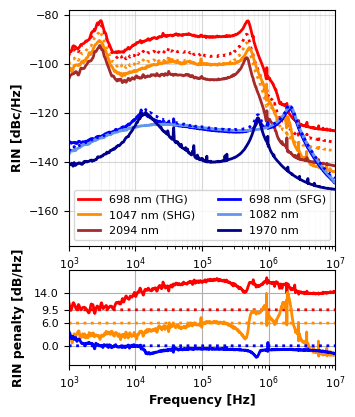

In [ ]:
fig, [axRIN,axP] = plt.subplots(nrows=2,ncols=1,figsize=(3.35,4.1),height_ratios=[5,2.]) #old figsize: figsize=(4.15,5.17)



marksize = 2
fontsize = 9
labelsize=8

# plt.plot(pump_freqs,THG_RIN_approx, 'y--',label = 'THG theory 2')


# plt.plot(SHG_freqs,cascaded_RIN_data_theory, '--',label = 'SHG + SFG uncorrelated data theory')

# plt.plot(SHG_freqs,cascaded_RIN_theory, '--',label = 'SHG + SFG uncorrelated theory')





axP.set_xlabel('Frequency [Hz]', fontweight='bold', fontsize=fontsize,labelpad=2.2)
axP.set_ylabel('RIN penalty [dB/Hz]',fontweight='bold', fontsize=fontsize,labelpad=7)

axRIN.set_ylabel('RIN [dBc/Hz]', fontweight='bold', fontsize=fontsize)

axRIN.xaxis.set_tick_params(labelsize=labelsize)
axRIN.yaxis.set_tick_params(labelsize=labelsize)
axP.xaxis.set_tick_params(labelsize=labelsize)
axP.yaxis.set_tick_params(labelsize=labelsize)


#THG
axRIN.plot(THG_freqs,THG_RIN, color='red', label='698 nm (THG)', linewidth=marksize)

axRIN.plot(pump_freqs,THG_theory_RIN, ':', color='red', label = '_nolegend_', linewidth=marksize)

axRIN.plot(SHG_freqs,SHG_RIN, color='darkorange', label='1047 nm (SHG)', linewidth=marksize)

axRIN.plot(pump_freqs,SHG_theory_RIN,':', color='darkorange',label='_nolegend_', linewidth=marksize)

axRIN.plot(pump_freqs,pump_RIN, color='brown', label='2094 nm', linewidth=marksize)

#SFG
axRIN.plot(SFG_freqs,SFG_RIN, color='blue', label='698 nm (SFG)', linewidth=marksize)

axRIN.plot(SFG_pump1_freqs,SFG_pump1_RIN, color='cornflowerblue', label='1082 nm', linewidth=marksize)
axRIN.plot(SFG_pump2_freqs,SFG_pump2_RIN, color='darkblue', label='1970 nm', linewidth=marksize)

axRIN.plot(SFG_freqs,SFG_theory_RIN, ':', color='blue', label='_nolegend_', linewidth=marksize)


fig.tight_layout()

axRIN.set_xscale('log')

fig.subplots_adjust(left=0.175, right=0.97, top=0.99, bottom=0.125, hspace = 0.15)
# fig.subplots_adjust(hspace=0.15)


axRIN.set_xlim([1e3,1e7])
axRIN.set_ylim([-174,-78])

axRIN.grid(True,which='minor',alpha=0.15)
axRIN.grid(True,which='major',alpha=0.5)
# axRIN.vlines(5e5,-np.inf,np.inf)

axRIN.set_yticks(np.arange(-160,-70,20))
# axRIN.set_xticks

axRIN.legend(ncol=2,fontsize=labelsize,loc='lower center')
# axRIN.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_data_theory.pdf")
# axRIN.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_data_theory.svg")



axP.plot(THG_freqs,THG_RIN-pump_RIN,color='red',label='THG', linewidth=marksize)
axP.plot(THG_freqs,THG_theory_RIN-pump_RIN, ':', color='red',label='_nolegend_', linewidth=marksize) #shot noise for THG data present? Also fits nicely with the RIN osc. freq. peak for the amplifier, possible that coupled amplitude alters something for laser peak?


axP.plot(SHG_freqs,SHG_RIN-pump_RIN,color='darkorange',label='SHG', linewidth=marksize)
axP.plot(SHG_freqs,SHG_theory_RIN-pump_RIN,':',color='darkorange',label='_nolegend_', linewidth=marksize) #shot noise for SHG data present?

SFG_pump_sum_RIN = linear_to_dB(dB_to_linear(SFG_pump1_RIN) + dB_to_linear(SFG_pump2_RIN))

axP.plot(SFG_freqs,SFG_RIN-SFG_pump_sum_RIN,color='blue',label='SFG', linewidth=marksize)
axP.plot(SFG_freqs,SFG_theory_RIN-SFG_pump_sum_RIN, ':', color='blue',label='_nolegend_', linewidth=marksize)



axP.set_xscale('log')

# axP.legend(fontsize=fontsize)
# axP.xlabel('Fourier frequency [Hz]')

axP.grid()
axP.set_ylim([-5,20])
axP.set_xlim([1e3,1e7])
axP.set_yticks([0,6,9.5,14])



# fig.align_ylabels([axRIN,axP])


# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_penalty.pdf")
# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_penalty.svg")

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_combined.svg")#, bbox_inches='tight')

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_combined.pdf")#, bbox_inches='tight')




In [ ]:

RIN_int_pump = linear_to_dB(integrated_RIN(pump_freqs,pump_RIN))

RIN_int_SHG_theory = linear_to_dB(integrated_RIN(pump_freqs,SHG_theory_RIN))

RIN_int_THG_theory = linear_to_dB(integrated_RIN(pump_freqs,THG_theory_RIN))

RIN_int_Cascaded_data_theory = linear_to_dB(integrated_RIN(SHG_freqs,cascaded_RIN_data_theory))

RIN_int_Cascaded_theory = linear_to_dB(integrated_RIN(pump_freqs,cascaded_RIN_data_theory))

RIN_int_SHG_data = linear_to_dB(integrated_RIN(SHG_freqs,SHG_RIN))

RIN_int_SFG_data = linear_to_dB(integrated_RIN(SFG_freqs,SFG_RIN))

RIN_int_THG_data = linear_to_dB(integrated_RIN(pump_freqs,THG_RIN))

print('Pump',RIN_int_pump, '\nSHG theory',RIN_int_SHG_theory, '\nSHG data',RIN_int_SHG_data, '\nTHG theory',RIN_int_THG_theory, '\nCascaded data theory',RIN_int_Cascaded_data_theory, '\nCascaded theory',RIN_int_Cascaded_theory, '\nTHG data',RIN_int_THG_data)


Pump -44.442807057541785 
SHG theory -38.42220714406245 
SHG data -39.271827730826885 
THG theory -34.90006969556286 
Cascaded data theory -38.1189848350993 
Cascaded theory -38.11898731865674 
THG data -28.694520459981586


In [ ]:
print(f'Difference for THG is: {RIN_int_THG_data-RIN_int_THG_theory:.2f} dB')
print(f'Difference for SHG is: {RIN_int_SHG_data-RIN_int_SHG_theory:.2f} dB')

Difference for THG is: 6.21 dB
Difference for SHG is: -0.85 dB


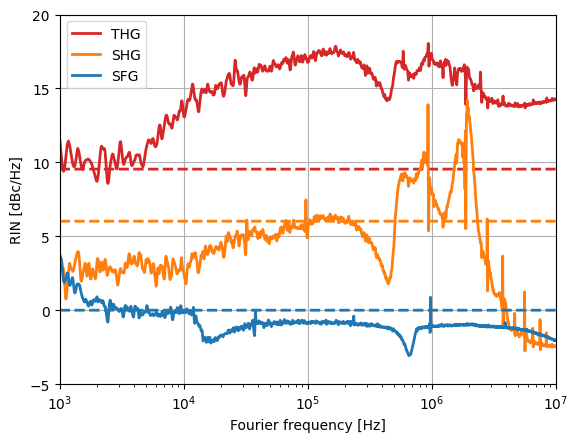

In [ ]:
plt.plot(THG_freqs,THG_RIN-pump_RIN,color='tab:red',label='THG', linewidth=marksize)
plt.plot(THG_freqs,THG_theory_RIN-pump_RIN, '--', color='tab:red',label='_nolegend_', linewidth=marksize) #shot noise for THG data present? Also fits nicely with the RIN osc. freq. peak for the amplifier, possible that coupled amplitude alters something for laser peak?


plt.plot(SHG_freqs,SHG_RIN-pump_RIN,color='tab:orange',label='SHG', linewidth=marksize)
plt.plot(SHG_freqs,SHG_theory_RIN-pump_RIN,'--',color='tab:orange',label='_nolegend_', linewidth=marksize) #shot noise for SHG data present?

SFG_pump_sum_RIN = linear_to_dB(dB_to_linear(SFG_pump1_RIN) + dB_to_linear(SFG_pump2_RIN))

plt.plot(SFG_freqs,SFG_RIN-SFG_pump_sum_RIN,color='tab:blue',label='SFG', linewidth=marksize)
plt.plot(SFG_freqs,SFG_theory_RIN-SFG_pump_sum_RIN, '--', color='tab:blue',label='_nolegend_', linewidth=marksize)



plt.xscale('log')

plt.legend()
plt.xlabel('Fourier frequency [Hz]')
plt.ylabel('RIN [dBc/Hz]')
plt.grid()
plt.ylim([-5,20])
plt.xlim([1e3,1e7])

plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_penalty.pdf")
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\RIN_spectrum_penalty.svg")


# plt.xlim([1e3,1e7])
# plt.ylim([-145,-80])
# plt.grid(True,'both')
# plt.vlines(5e5,-np.inf,np.inf)

In [ ]:
num_values = 1000

# RIN_int_pump_values = np.linspace(-100,90,num_values) #for generating flat noise spectrum

# avg_RIN_spec_pump_values = linear_to_dB(dB_to_linear(RIN_int_pump_values)/(pump_freqs[-1]-pump_freqs[0]))

avg_RIN_spec_pump_values = np.logspace(-1,8,num_values) #Multiplied to our actual measured pump noise spectrum



num_points = len(pump_freqs)

# input_RIN_spec_values = np.ones(num_values)
# SHG_theory_RIN_spec_calc = np.ones(num_values)
# SFG_theory_RIN_spec_calc = np.ones(num_values)
# THG_theory_RIN_spec_calc = np.ones(num_values)
# SHG_approx_RIN_spec_calc = np.ones(num_values)
# SFG_approx_RIN_spec_calc = np.ones(num_values)
# THG_approx_RIN_spec_calc = np.ones(num_values)




RIN_int_pump_calc = np.ones((num_values))
RIN_int_SHG_calc = np.ones((num_values))
RIN_int_SFG_calc = np.ones((num_values))
RIN_int_THG_calc = np.ones((num_values))
RIN_int_Cascaded_calc = np.ones((num_values))

RIN_int_SHG_approx_calc = np.ones((num_values))
RIN_int_SFG_sum_p1_p_2 = np.ones((num_values))
RIN_int_THG_approx_calc = np.ones((num_values))

delta_diff_check_SHG = np.ones((num_values))
delta_diff_check_THG = np.ones((num_values))





RIN_squared_int = np.ones((num_values))

RIN_tripled_int = np.ones((num_values))

variance_offset_int = np.ones((num_values))   

variance_squared_offset_int = np.ones((num_values))   

RIN_variance_int = np.ones((num_values))   

RIN_variance_squared_int = np.ones((num_values))   





for i,avg_RIN_pump_value in enumerate(avg_RIN_spec_pump_values):
    #avg_RIN_spec_pump = np.ones((num_points))*avg_RIN_pump_value

    modified_RIN_input =  linear_to_dB(dB_to_linear(pump_RIN) * avg_RIN_pump_value)  #Multiply RIN input spectrum with values above in linear scale and insert that as x-scale when integrated 
    
    avg_RIN_spec_pump = modified_RIN_input

    SHG_theory_RIN = SHG_RIN_spec(avg_RIN_spec_pump) #from dB to dB
    THG_theory_RIN = THG_RIN_spec(pump_freqs,avg_RIN_spec_pump)
    cascaded_RIN_theory = SFG_RIN_spec(avg_RIN_spec_pump,SHG_theory_RIN)

    SFG_theory_RIN = SFG_RIN_spec(avg_RIN_spec_pump,avg_RIN_spec_pump)

    SHG_approx_RIN = approx_SHG_RIN_spec(avg_RIN_spec_pump)
    SFG_sum_p1_p2_RIN = linear_to_dB( dB_to_linear(avg_RIN_spec_pump) + dB_to_linear(avg_RIN_spec_pump) )
    THG_approx_RIN = approx_THG_RIN_spec(avg_RIN_spec_pump)

    pump_int_RIN = integrated_RIN(pump_freqs,avg_RIN_spec_pump)

    # input_RIN_spec_values[i] = avg_RIN_spec_pump[0]
    # SHG_theory_RIN_spec_calc[i] = SHG_theory_RIN[0]
    # THG_theory_RIN_spec_calc[i] = THG_theory_RIN[0]
    # SHG_approx_RIN_spec_calc[i] = SHG_approx_RIN[0]
    # THG_approx_RIN_spec_calc[i] = THG_approx_RIN[0]
 

    RIN_int_pump_calc[i] = linear_to_dB(pump_int_RIN) # sanity check

    RIN_int_SHG_calc[i] = linear_to_dB(integrated_RIN(pump_freqs,SHG_theory_RIN) + pump_int_RIN**2) #Adding the delta function, that gives an addition of int. RIN^2. 
    RIN_int_SFG_calc[i] = linear_to_dB(integrated_RIN(pump_freqs,SFG_theory_RIN)) #Integrated RIN: dB to linear
    RIN_int_THG_calc[i] = linear_to_dB(integrated_RIN(pump_freqs,THG_theory_RIN) + 9 * pump_int_RIN**2) #Adding the delta function, that gives an addition of int. 9 RIN^2) 

    delta_diff_check_SHG[i] = linear_to_dB(integrated_RIN(pump_freqs,SHG_theory_RIN))
    delta_diff_check_THG[i] = linear_to_dB(integrated_RIN(pump_freqs,THG_theory_RIN))


    RIN_int_Cascaded_calc[i] = linear_to_dB(integrated_RIN(pump_freqs,cascaded_RIN_theory)) 

    RIN_int_SHG_approx_calc[i] = linear_to_dB(integrated_RIN(pump_freqs,SHG_approx_RIN))
    RIN_int_SFG_sum_p1_p_2[i] = linear_to_dB(integrated_RIN(pump_freqs,SFG_sum_p1_p2_RIN))
    RIN_int_THG_approx_calc[i] = linear_to_dB(integrated_RIN(pump_freqs,THG_approx_RIN))




    RIN_sq = RIN_squared(avg_RIN_spec_pump)

    RIN_tri = RIN_tripled(avg_RIN_spec_pump)

    var_off = variance_offset(pump_freqs, avg_RIN_spec_pump)

    var_sq_off = variance_squared_offset(pump_freqs, avg_RIN_spec_pump)

    RIN_var = RIN_variance(pump_freqs, avg_RIN_spec_pump)

    RIN_var_sq = RIN_variance_squared(pump_freqs, avg_RIN_spec_pump)




    RIN_squared_int[i] = linear_to_dB(integrated_RIN(pump_freqs,RIN_sq))
    RIN_tripled_int[i] = linear_to_dB(integrated_RIN(pump_freqs,RIN_tri))

    variance_offset_int[i] = var_off
    variance_squared_offset_int[i] = var_sq_off

    RIN_variance_int[i] = linear_to_dB(integrated_RIN(pump_freqs,RIN_var))
    RIN_variance_squared_int[i] =  linear_to_dB(integrated_RIN(pump_freqs,RIN_var_sq))


#Comparison of terms






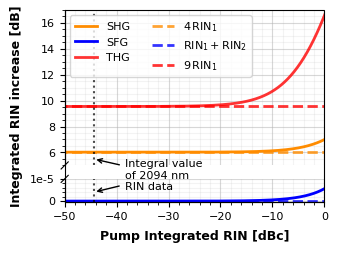

In [ ]:
RIN_int_pump_values = RIN_int_pump_calc



plt.figure(figsize=(3.35,2.5))

bax = brokenaxes(ylims=((-5e-7,1e-5),(5,17)),hspace=0.15,height_ratios=(1,0.15))


# plt.plot(RIN_int_pump_values,RIN_int_pump_calc-RIN_int_pump_values, label='Pump', color = 'brown',linewidth=marksize)

bax.plot(RIN_int_pump_values,RIN_int_SHG_calc-RIN_int_pump_values, label='SHG', color = 'darkorange',linewidth=marksize)

bax.plot(RIN_int_pump_values,RIN_int_SFG_calc-RIN_int_SFG_sum_p1_p_2, label='SFG', color = 'blue',linewidth=marksize)

bax.plot(RIN_int_pump_values,RIN_int_THG_calc-RIN_int_pump_values, label='THG', color = 'red', alpha = 0.8, linewidth=marksize)

# plt.plot(RIN_int_pump_values,RIN_int_Cascaded_calc, label='Cascaded unc. int. RIN')



bax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc-RIN_int_pump_values, ls='--', color = 'darkorange',  label=r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

bax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2-RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'


bax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc-RIN_int_pump_values, ls='--', color = 'red', label=r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'

# plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

# plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange')

# plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red')

# plt.plot(RIN_int_pump,RIN_int_Cascaded_data_theory,'.',color='tab:red')


marksize = 2
fontsize = 9
labelsize =8
bax.legend(ncol=2,loc='upper left',fontsize=labelsize)

# plt.vlines(x=[RIN_int_pump_values[700]],ymin=-100,ymax=40,ls='--',color='k')#1% increase between higher order and approximation
# plt.vlines(x=[RIN_int_pump_values[790]],ymin=-100,ymax=40,ls='--',color='k')#10% increase
# plt.vlines(x=[RIN_int_pump_values[850]],ymin=-100,ymax=40,ls='--',color='k')#%50% increase

bax.grid()
bax.set_xlim([-50,0])
# plt.ylim([-.0000001,.00001])
bax.set_xlabel('Pump Integrated RIN [dBc]', fontweight='bold', fontsize=fontsize,labelpad=20)
bax.set_ylabel('Integrated RIN increase [dB]',fontweight='bold', fontsize=fontsize, labelpad=30)


for ax in bax.axs:
    ax.minorticks_on()
    ax.grid(True,which='minor',alpha=0.15)
    ax.grid(True,which='major',alpha=0.5)

    ax.axvline(x=RIN_int_pump,color='black',linestyle=':',linewidth=marksize-0.5, alpha=0.7)

bax.tick_params(axis='x',labelsize=labelsize)
bax.tick_params(axis='y',labelsize=labelsize)

bax.axs[0].tick_params(axis='x',which='both',bottom=False,top=False,labelbottom=False)


current_ticks = plt.xticks()[0]  # Get tick locations
current_labels = [label.get_text() for label in plt.xticks()[1]]

bax.axs[1].set_yticks([0,1e-5])
bax.axs[1].set_yticklabels(['0', '1e-5'])

bax.axs[0].set_yticks([6,8,10,12,14,16])
bax.axs[0].set_yticklabels(['6','8','10','12','14','16'])

bax.axs[1].annotate('Integral value\nof 2094 nm\nRIN data', xy=(RIN_int_pump, 4e-6),xytext=(RIN_int_pump+6, 5e-6), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)
bax.axs[0].annotate('', xy=(RIN_int_pump, 5.5), xytext=(RIN_int_pump+5.5, 5), arrowprops=dict(arrowstyle='->', color='k', lw=1), fontsize=labelsize)

# fig.tight_layout()

# Add after all plotting commands (just before savefig)
# rect = patches.Rectangle((0, 0), 1, 1,
#                              transform=bax.fig.transFigure,
#                         fill=False, color='black', linewidth=1)
# bax.fig.patches.append(rect)

# for ax in bax.axs:
#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_linewidth(0.8)  # adjust thickness if you want

# # Draw a single outer frame around the entire brokenaxes area
# bbox = bax.figbox()  # coordinates of the brokenaxes in figure units
# fig = bax.fig
# rect = plt.Rectangle(
#     (bbox.x0, bbox.y0),
#     bbox.width,
#     bbox.height,
#     transform=fig.transFigure,
#     color='black',
#     fill=False,
#     lw=0.8
# )
# fig.patches.append(rect)



fig = bax.fig

# ensure positions are up-to-date
# fig.tight_layout()
fig.canvas.draw()

# get the positions (Bbox) of all internal axes (in figure coords)
bboxes = [ax.get_position() for ax in bax.axs]

# compute union bbox (min x0,y0 and max x1,y1)
x0 = min(b.x0 for b in bboxes)
y0 = min(b.y0 for b in bboxes)
x1 = max(b.x1 for b in bboxes)
y1 = max(b.y1 for b in bboxes)

# optional padding in figure coordinates (tiny fraction)
pad = 0.008

# draw rectangle in figure coordinates
rect = plt.Rectangle(
    (x0, y0),
    (x1 - x0),
    (y1 - y0),
    transform=fig.transFigure,
    fill=False,
    linewidth=0.8,
    edgecolor='black',
    zorder=10
)
fig.patches.append(rect)



# updated_ticks = np.append(current_ticks, RIN_int_pump)
# updated_labels = current_labels + [r'$\frac{\sigma_1^2}{\overline{I}_1^2}$']
# sorted_indices = np.argsort(updated_ticks)
# final_ticks = updated_ticks[sorted_indices]
# final_labels = [updated_labels[i] for i in sorted_indices]
# bax.set_xticks(final_ticks, final_labels)


plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Int_RIN_spectrum_approx_vs_higher_order.pdf",bbox_inches='tight')
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Int_RIN_spectrum_approx_vs_higher_order.svg",bbox_inches='tight')



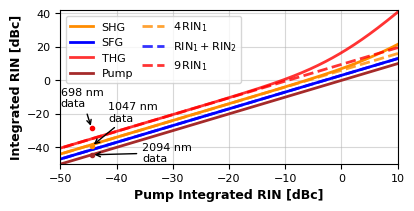

In [ ]:
RIN_int_pump_values = RIN_int_pump_calc



fig, ax = plt.subplots(figsize=(4.35,2))


ax.plot(RIN_int_pump_values,RIN_int_SHG_calc, label='SHG', color = 'darkorange',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='SFG', color = 'blue',linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_THG_calc, label='THG', color = 'red', alpha = 0.8, linewidth=marksize)

ax.plot(RIN_int_pump_values,RIN_int_pump_calc, label='Pump', color = 'brown',linewidth=marksize)

# plt.plot(RIN_int_pump_values,RIN_int_Cascaded_calc, label='Cascaded unc. int. RIN')



ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc, ls='--', color = 'darkorange', label = r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'


ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc, ls='--', color = 'red', label = r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'


# plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

# plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange')

# plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red')

# plt.plot(RIN_int_pump,RIN_int_Cascaded_data_theory,'.',color='tab:red')


marksize = 2
fontsize = 9
labelsize =8
ax.legend(ncol=2,loc='upper left',fontsize=labelsize, columnspacing = 0.8)

# plt.vlines(x=[RIN_int_pump_values[700]],ymin=-100,ymax=40,ls='--',color='k')#1% increase between higher order and approximation
# plt.vlines(x=[RIN_int_pump_values[790]],ymin=-100,ymax=40,ls='--',color='k')#10% increase
# plt.vlines(x=[RIN_int_pump_values[850]],ymin=-100,ymax=40,ls='--',color='k')#%50% increase

ax.grid()
ax.set_xlim([-50,10])
ax.set_ylim([-50,42])
# plt.ylim([-.0000001,.00001])
ax.set_xlabel('Pump Integrated RIN [dBc]', fontweight='bold', fontsize=fontsize,labelpad=3)
ax.set_ylabel('Integrated RIN [dBc]',fontweight='bold', fontsize=fontsize, labelpad=3)

# ax.minorticks_on()
ax.grid(True,which='minor',alpha=0.15)
ax.grid(True,which='major',alpha=0.5)

# ax.axvline(x=RIN_int_pump,color='black',linestyle=':',linewidth=marksize-0.5, alpha=0.4)

ax.tick_params(axis='x',labelsize=labelsize)
ax.tick_params(axis='y',labelsize=labelsize)



ax.annotate('2094 nm\ndata', xy=(RIN_int_pump, RIN_int_pump),xytext=(RIN_int_pump+9, -48.5), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)
ax.annotate('1047 nm\ndata', xy=(RIN_int_pump, RIN_int_SHG_data),xytext=(RIN_int_pump+3, RIN_int_SHG_data+15), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)

ax.annotate('698 nm\ndata', xy=(RIN_int_pump, RIN_int_THG_data),xytext=(RIN_int_pump-5.5, RIN_int_THG_data+13), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)



plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange',linewidth=marksize)

plt.plot(RIN_int_pump,RIN_int_SFG_data,'.',color='blue',linewidth=marksize)

plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red',linewidth=marksize)


# inset_ax = inset_axes(ax, width="30%",height="30%",loc='lower left',bbox_to_anchor=(0.67,0.08,.9,.9),bbox_transform=ax.transAxes)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='_nolegend_', color = 'blue',linewidth=marksize)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = '_nolegend_', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'
# inset_ax.set_ylim([3.010257,3.0104])
# inset_ax.set_xlim([0,1e-4])
# inset_ax.grid()


# current_ticks = plt.xticks()[0]  # Get tick locations
# current_labels = [label.get_text() for label in plt.xticks()[1]]
# 
# updated_ticks = np.append(current_ticks, RIN_int_pump)
# updated_labels = current_labels + ['2094\nnm\nRIN\ndata']
# sorted_indices = np.argsort(updated_ticks)
# final_ticks = updated_ticks[sorted_indices]
# final_labels = [updated_labels[i] for i in sorted_indices]
# ax.set_xticks(final_ticks, final_labels)


plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.pdf")#,bbox_inches='tight')
plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.svg")#,bbox_inches='tight')



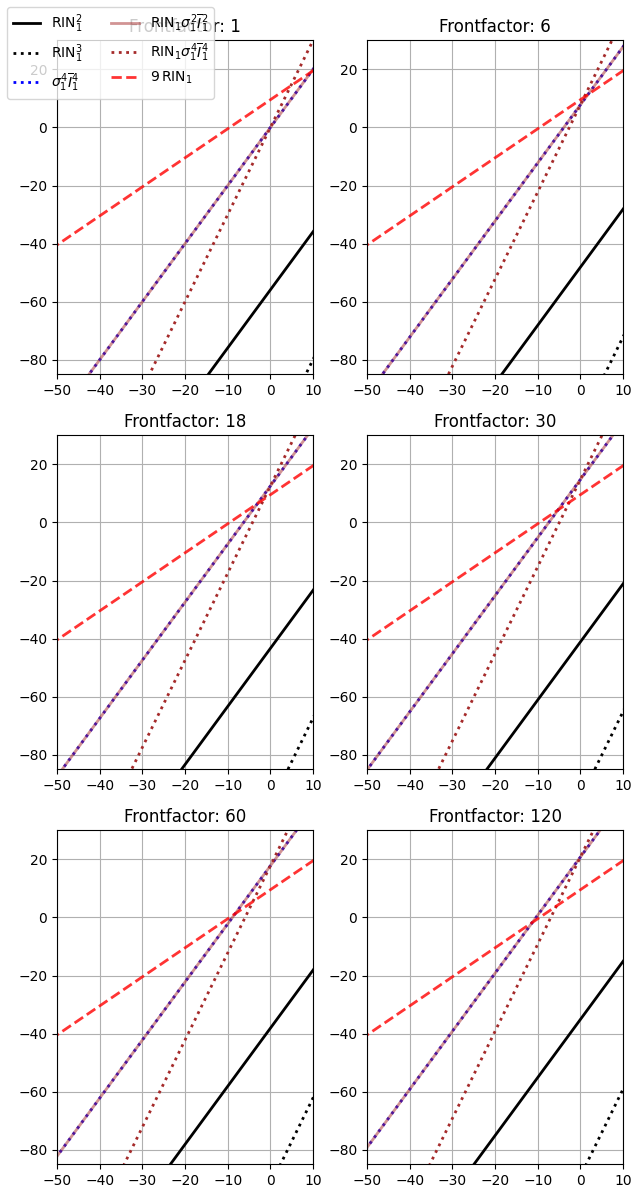

In [ ]:
RIN_int_pump_values = RIN_int_pump_calc



fig, axes = plt.subplots(3,2,figsize=(6.35,12))


mult = [4,9]

frontfac = [1,6,18,30,60,120]

for i, ax in enumerate(axes.flatten()):

        RIN_comp = 0*mult[1]*dB_to_linear(RIN_int_pump_values)

        RIN_sq = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_squared_int)) 

        RIN_tri = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_tripled_int)) 

        RIN_var_off = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(variance_offset_int)) 

        RIN_var_sq_off = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(variance_squared_offset_int)) 

        RIN_RIN_var = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_variance_int)) 

        RIN_RIN_var_sq = linear_to_dB( RIN_comp + frontfac[i]*dB_to_linear(RIN_variance_squared_int))


        ax.plot(RIN_int_pump_values,  RIN_sq , color='black',ls='-', linewidth=marksize, label=r'$\mathrm{RIN}_1^2$')

        ax.plot(RIN_int_pump_values, RIN_tri, color='black', ls=':', linewidth=marksize, label=r'$\mathrm{RIN}_1^3$')

        # ax.plot(RIN_int_pump_values,RIN_var_off, color='blue', ls='-', linewidth=marksize, label=r'$\sigma_1^2 \overline{I}_1^2$')

        ax.plot(RIN_int_pump_values,RIN_var_sq_off, color='blue', ls=':', linewidth=marksize, label=r'$\sigma_1^4 \overline{I}_1^4$')

        ax.plot(RIN_int_pump_values,RIN_RIN_var,color='brown', ls='-', linewidth=marksize, label=r'$\mathrm{RIN}_1 \sigma_1^2 \overline{I}_1^2$',alpha=0.5)

        ax.plot(RIN_int_pump_values,RIN_RIN_var_sq,color='brown', ls=':', linewidth=marksize, label=r'$\mathrm{RIN}_1 \sigma_1^4 \overline{I}_1^4$')

        # ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc, ls='--', color = 'darkorange', label = r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

        ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc, ls='--', color = 'red', label = r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'

        ax.set_xlim(-50,10)
        ax.set_ylim(-85,30)
        ax.grid()
        ax.set_title(f'Frontfactor: {frontfac[i]}')


# Create a single legend for the entire figure
handles, labels = ax.get_legend_handles_labels()  # Get from last subplot (or any)
fig.legend(handles, labels, loc='upper left', ncol=2)  # Adjust location & columns

plt.tight_layout()
plt.show()


# ax.plot(RIN_int_pump_values,RIN_int_SHG_calc, label='SHG', color = 'darkorange',linewidth=marksize)

# ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='SFG', color = 'blue',linewidth=marksize)

# ax.plot(RIN_int_pump_values,RIN_int_THG_calc, label='THG', color = 'red', alpha = 0.8, linewidth=marksize)

# ax.plot(RIN_int_pump_values,RIN_int_pump_calc, label='Pump', color = 'brown',linewidth=marksize)

# plt.plot(RIN_int_pump_values,RIN_int_Cascaded_calc, label='Cascaded unc. int. RIN')



# ax.plot(RIN_int_pump_values,RIN_int_SHG_approx_calc, ls='--', color = 'darkorange', label = r'$4\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$4\,\mathrm{RIN}_1$'

# ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'


# ax.plot(RIN_int_pump_values,RIN_int_THG_approx_calc, ls='--', color = 'red', label = r'$9\,\mathrm{RIN}_1$', alpha = 0.8, linewidth=marksize) # label=r'$9\,\mathrm{RIN}_1$'


# plt.plot(RIN_int_pump,RIN_int_pump,'.',color='brown')

# plt.plot(RIN_int_pump,RIN_int_SHG_data,'.',color='darkorange')

# plt.plot(RIN_int_pump,RIN_int_THG_data,'.',color='red')

# plt.plot(RIN_int_pump,RIN_int_Cascaded_data_theory,'.',color='tab:red')


# marksize = 2
# fontsize = 9
# labelsize =8
# ax.legend(ncol=2,loc='upper left',fontsize=labelsize, columnspacing = 0.8)

# # plt.vlines(x=[RIN_int_pump_values[700]],ymin=-100,ymax=40,ls='--',color='k')#1% increase between higher order and approximation
# # plt.vlines(x=[RIN_int_pump_values[790]],ymin=-100,ymax=40,ls='--',color='k')#10% increase
# # plt.vlines(x=[RIN_int_pump_values[850]],ymin=-100,ymax=40,ls='--',color='k')#%50% increase

# ax.grid()
# ax.set_xlim([-50,10])
# ax.set_ylim([-50,42])
# # plt.ylim([-.0000001,.00001])
# ax.set_xlabel('Pump Integrated RIN [dBc]', fontweight='bold', fontsize=fontsize,labelpad=3)
# ax.set_ylabel('Integrated RIN [dBc]',fontweight='bold', fontsize=fontsize, labelpad=3)

# # ax.minorticks_on()
# ax.grid(True,which='minor',alpha=0.15)
# ax.grid(True,which='major',alpha=0.5)

# # ax.axvline(x=RIN_int_pump,color='black',linestyle=':',linewidth=marksize-0.5, alpha=0.4)

# ax.tick_params(axis='x',labelsize=labelsize)
# ax.tick_params(axis='y',labelsize=labelsize)



# ax.annotate('2094 nm\ndata', xy=(RIN_int_pump, RIN_int_pump),xytext=(RIN_int_pump+9, -48.5), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)
# .5
# ax.annotate('1047 nm\ndata', xy=(RIN_int_pump, RIN_int_SHG_data),xytext=(RIN_int_pump+3, RIN_int_SHG_data+15), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)

# ax.annotate('698 nm\ndata', xy=(RIN_int_pump, RIN_int_THG_data),xytext=(RIN_int_pump-5.5, RIN_int_THG_data+13), arrowprops=dict(arrowstyle='->',color='k',lw=1),fontsize=labelsize)




# inset_ax = inset_axes(ax, width="30%",height="30%",loc='lower left',bbox_to_anchor=(0.67,0.08,.9,.9),bbox_transform=ax.transAxes)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_calc, label='_nolegend_', color = 'blue',linewidth=marksize)
# inset_ax.plot(RIN_int_pump_values,RIN_int_SFG_sum_p1_p_2, ls='--', color = 'blue', label = '_nolegend_', alpha = 0.8, linewidth=marksize) # label=r'$\mathrm{RIN}_1 + \mathrm{RIN}_2$'
# inset_ax.set_ylim([3.010257,3.0104])
# inset_ax.set_xlim([0,1e-4])
# inset_ax.grid()


# current_ticks = plt.xticks()[0]  # Get tick locations
# current_labels = [label.get_text() for label in plt.xticks()[1]]
# 
# updated_ticks = np.append(current_ticks, RIN_int_pump)
# updated_labels = current_labels + ['2094\nnm\nRIN\ndata']
# sorted_indices = np.argsort(updated_ticks)
# final_ticks = updated_ticks[sorted_indices]
# final_labels = [updated_labels[i] for i in sorted_indices]
# ax.set_xticks(final_ticks, final_labels)


# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.pdf")#,bbox_inches='tight')
# plt.savefig(r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Figures\RIN freq conversion\Sup_Int_RIN_spectrum_approx_vs_higher_order.svg")#,bbox_inches='tight')



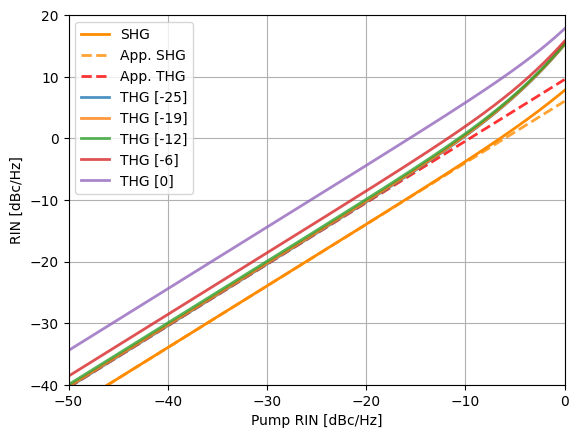

In [ ]:
num_plots = 5
input_binned_RIN_spec_powers_dB = linear_to_dB( np.logspace(-18,10,int(1e5)) ) #in dB
int_RIN_values_dB = linear_to_dB( np.logspace(-2.5,0,num_plots) )


    
SHG_binned_RIN_spec_powers = SHG_RIN_spec(input_binned_RIN_spec_powers_dB) #reduced RIN (Isserlis' theorem applied) without dirac delta function. Input and output RIN is in dB/Hz

SHG_approx_binned_RIN_spec_powers = approx_SHG_RIN_spec(input_binned_RIN_spec_powers_dB)
THG_approx_binned_RIN_spec_powers = approx_THG_RIN_spec(input_binned_RIN_spec_powers_dB)


plt.figure()
plt.plot(input_binned_RIN_spec_powers_dB,SHG_binned_RIN_spec_powers, label='SHG', color = 'darkorange',linewidth=marksize)


plt.plot(input_binned_RIN_spec_powers_dB,SHG_approx_binned_RIN_spec_powers, ls='--', color = 'darkorange', label='App. SHG', alpha = 0.8, linewidth=marksize)
plt.plot(input_binned_RIN_spec_powers_dB,THG_approx_binned_RIN_spec_powers, ls='--', color = 'red', label='App. THG', alpha = 0.8, linewidth=marksize)


THG_binned_RIN_spec_powers = [[]]*num_plots

for i,int_RIN in enumerate(int_RIN_values_dB):
    THG_binned_RIN_spec_powers[i] = THG_RIN_spec_var(input_binned_RIN_spec_powers_dB,int_RIN)

    plt.plot(input_binned_RIN_spec_powers_dB,THG_binned_RIN_spec_powers[i], label=f'THG [{int_RIN:.0f}]', alpha = 0.8, linewidth=marksize)





plt.grid()
plt.xlim([-50,0])
plt.ylim([-40,20])
plt.xlabel('Pump RIN [dBc/Hz]')
plt.ylabel('RIN [dBc/Hz]')
plt.legend()

In [ ]:
diff_approx = RIN_int_THG_calc[504]-RIN_int_THG_approx_calc[504]

diff_percent = dB_to_linear(diff_approx)*100-100


In [ ]:
print(f'Average pump RIN spectra levels for THG increase due to higher-order moments \n1%: {avg_RIN_spec_pump_values[700]:.2f} dB \n10%: {avg_RIN_spec_pump_values[790]:.2f} dB \n50%: {avg_RIN_spec_pump_values[850]:.2f} dB \nData avg. pump RIN level: {avg_RIN_spec_pump_values[504]:.2f} dB \nDifference compared to approximation: {diff_percent:.4f}% ')

Average pump RIN spectra levels for THG increase due to higher-order moments 
1%: 202444.65 dB 
10%: 1309535.02 dB 
50%: 4546295.47 dB 
Data avg. pump RIN level: 3471.69 dB 
Difference compared to approximation: 39.0018% 


In [ ]:
#Trapezoidal rule, used due to linear interpolation 

pump_RIN_lin = 10**(pump_RIN/10)

SHG_RIN_lin = 10**(SHG_RIN/10)


THG_RIN_lin = 10**(THG_RIN/10)


pump_RIN_integ =  10*np.log10( np.trapz(pump_RIN_lin,pump_freqs))

SHG_RIN_integ = 10*np.log10(np.trapz(SHG_RIN_lin,SHG_freqs))

THG_RIN_integ = 10*np.log10(np.trapz(THG_RIN_lin,THG_freqs))

THG_int  = 0 
for i in range(len(THG_freqs)-1):
    
    THG_int += (THG_RIN_lin[i]+THG_RIN_lin[i+1])/2 * (THG_freqs[i+1]-THG_freqs[i])

np.isclose(THG_RIN_integ,10*np.log10(THG_int))

True

In [ ]:
SHG_RIN_integ- pump_RIN_integ

5.1709793267149

In [ ]:
print(f'Difference in dB: {THG_RIN_integ-pump_RIN_integ:.2f}')

print(f'Factor of { 10**((THG_RIN_integ-pump_RIN_integ )/10):.2f} larger' )

Difference in dB: 15.75
Factor of 37.57 larger


In [25]:


freqs_lin_fine = np.linspace(1e3,5e7,int(1e6))
freqs_lin_coarse = np.linspace(1e3,5e7,int(1e5))

freqs_log = np.logspace(3,7.69,5973)

rin_spectrum_lin_fine =model_RIN_spec(freqs_lin_fine)
rin_spectrum_lin_coarse =model_RIN_spec(freqs_lin_coarse)
rin_spectrum_log =model_RIN_spec(freqs_log)

freqs_inter_lin = np.linspace(freqs_log[0],freqs_log[-1],20*len(freqs_log))
interp = PchipInterpolator(freqs_log,rin_spectrum_log)

RIN_inter_lin = interp(freqs_inter_lin)


df_fine = freqs_lin_fine[1]-freqs_lin_fine[0]

df_coarse = freqs_lin_coarse[1]-freqs_lin_coarse[0]


H_fine = fftconvolve(rin_spectrum_lin_fine,rin_spectrum_lin_fine,mode='same') * df_fine

H_coarse = fftconvolve(rin_spectrum_lin_coarse,rin_spectrum_lin_coarse,mode='same') * df_coarse


rel_error = np.max(np.abs(H_coarse - H_fine)) / np.max(H_fine)



plt.plot(freqs_lin,linear_to_dB(rin_spectrum_lin),'.',label='linearly spaced')
# plt.plot(freqs_log,linear_to_dB(rin_spectrum_log),'.',label='log spaced')
plt.plot(freqs_inter_lin,linear_to_dB(RIN_inter_lin),'.',label='log lin interpolated')
# plt.xscale('log')
plt.xlim([1e3,5e3])
plt.legend()
plt.grid(which='both')

ValueError: operands could not be broadcast together with shapes (100000,) (1000000,) 

In [ ]:


def interpolation_back_on_orig_grid(f_log, RIN_log, N_lin):
    # 1. uniform linear grid
    f_lin = np.linspace(f_log.min(), f_log.max(), N_lin)
    df = f_lin[1] - f_lin[0]

    # 2. interpolate RIN onto linear grid
    interp_RIN = PchipInterpolator(f_log, RIN_log)
    RIN_lin = interp_RIN(f_lin)

    # 3. restrict convolution to original spectrum
    interp_log = interp1d(
        f_lin, RIN_lin,
        kind='linear',
        bounds_error=False,
        fill_value=0.0
    )

    lin_on_orig = interp_log(f_log)

    return lin_on_orig



def self_convolution_on_orig_grid(f_log, RIN_log, N_lin):
    # 1. uniform linear grid
    f_lin = np.linspace(f_log.min(), f_log.max(), N_lin)
    df = f_lin[1] - f_lin[0]

    # 2. interpolate RIN onto linear grid
    interp_RIN = PchipInterpolator(f_log, RIN_log)
    RIN_lin = interp_RIN(f_lin)

    # 3. FFT self-convolution
    H_full = fftconvolve(RIN_lin, RIN_lin, mode='full') * df
    f_H = np.linspace(2*f_lin[0], 2*f_lin[-1], len(H_full))

    # 4. restrict convolution to original spectrum
    interp_H = interp1d(
        f_H, H_full,
        kind='linear',
        bounds_error=False,
        fill_value=0.0
    )

    H_on_orig = interp_H(f_log)

    return H_on_orig


def rel_rms_error(S_ref, S):
    num = np.sqrt(np.mean((S_ref - S)**2))

    den = np.sqrt(np.mean(S_ref**2))

    return num/den

def rms_rel_error(S_ref, S):

    sre = 0

    for i in range(len(S_ref)):


        if S_ref[i] != 0:
            sre += ((S[i] - S_ref[i])/S_ref[i])**2 
        # else
        #     msre += 0

    rmsre = np.sqrt(sre / len(S_ref))

    return rmsre



In [69]:
pump_RIN

array([-106.151, -106.091, -106.032, ..., -141.484, -141.49 , -141.502])

In [134]:
#Convergence test

N_lin = [1e3,5e3,1e4,5e4,1e5,5e5,1e6,5e6,1e7,5e7,1e8]

interp_results = []

conv_results = []

RIN_log = model_RIN_spec(pump_freqs)

for N in N_lin:
    interp_back = interpolation_back_on_orig_grid(pump_freqs,RIN_log,int(N))
    interp_results.append(interp_back)

    conv = self_convolution_on_orig_grid(pump_freqs,RIN_log,int(N))

    conv_results.append(conv)


interp_ref = RIN_log
conv_ref = conv_results[-1]

rel_error_interp = []
rel_error_conv = []
rel_step_error_conv =[]


rel_rms_error_interp = []
rel_rms_error_conv = []

rms_rel_error_interp = []
rms_rel_error_conv = []



for i in range(len(N_lin)):
    err_interp = np.max (np.abs (np.abs( interp_results[i]-interp_ref) / interp_ref) )
    rel_error_interp.append(err_interp)

    rrmse = rel_rms_error(interp_ref,interp_results[i])
    rmsre = rms_rel_error(interp_ref,interp_results[i])

    rel_rms_error_interp.append(rrmse)
    rms_rel_error_interp.append(rmsre)


for i in range(len(N_lin)-2):
    err_conv = np.nanmax (np.abs (np.abs( conv_results[i]-conv_ref) / conv_ref) )
    step_err_conv = np.nanmax (np.abs (np.abs( conv_results[i]-conv_results[i+2]) / conv_results[i+2]) )

    rel_error_conv.append(err_conv)
    rel_step_error_conv.append(step_err_conv)


    rrmse = rel_rms_error(conv_results[i+2],conv_results[i])
    rmsre = rms_rel_error(conv_results[i+2],conv_results[i])

    rel_rms_error_conv.append(rrmse)
    rms_rel_error_conv.append(rmsre)



C:\Users\au617810\AppData\Local\Temp\ipykernel_15352\106038256.py:48: RuntimeWarning: invalid value encountered in divide
  err_conv = np.nanmax (np.abs (np.abs( conv_results[i]-conv_ref) / conv_ref) )
C:\Users\au617810\AppData\Local\Temp\ipykernel_15352\106038256.py:49: RuntimeWarning: invalid value encountered in divide
  step_err_conv = np.nanmax (np.abs (np.abs( conv_results[i]-conv_results[i+2]) / conv_results[i+2]) )


In [135]:
rel_rms_error_interp, rms_rel_error_interp

([0.8952680570683199,
  0.47130391381213044,
  0.10047640281853959,
  0.01132564942341571,
  0.002849902772378193,
  0.00011438378059052727,
  2.875504257741342e-05,
  1.1343498778374404e-06,
  2.7971693904884096e-07,
  1.1091835283340567e-08,
  2.8587408492301367e-09],
 [0.2672876927093794,
  0.9451947051377758,
  0.20056649983971836,
  0.008396434358697564,
  0.002093206522829131,
  8.364144307924855e-05,
  2.0913234488788454e-05,
  8.365687543445351e-07,
  2.0860811944635245e-07,
  8.39781861201305e-09,
  2.0656242775138704e-09])

In [136]:
rel_rms_error_conv, rms_rel_error_conv

([0.12614608479231584,
  0.14357224143232117,
  0.010914391878490168,
  0.0012526937991660528,
  0.0005576741552413104,
  0.00010395329784018136,
  5.162881946564424e-05,
  1.0275035001569652e-05,
  5.134626434190258e-06],
 [0.7709941219093082,
  4.810993321032619,
  1.1886653148997426,
  0.2947531700712267,
  0.20338288063876772,
  0.07916079049014221,
  0.04811947244542104,
  0.011997079095581209,
  0.006204937570155469])

C:\Users\au617810\AppData\Local\Temp\ipykernel_15352\3750728741.py:8: RuntimeWarning: divide by zero encountered in log10
  return 10*np.log10(RIN_lin)


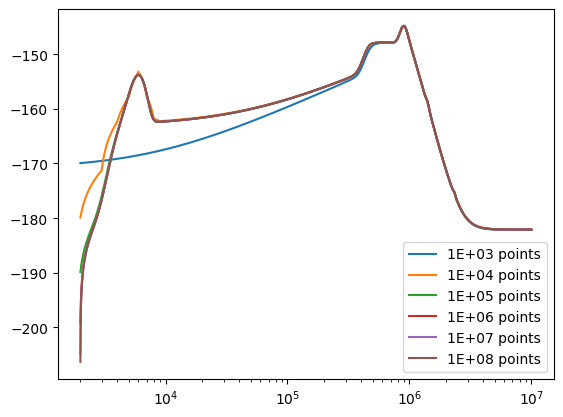

In [86]:
for i in range(0,len(N_lin)):
    plt.plot(pump_freqs,linear_to_dB(conv_results[i]),label=f'{N_lin[i]:.0E} points')
plt.xscale('log')
plt.legend()

In [ ]:
rel_error_interp

[0.9525383867773464,
 0.9405824250245193,
 0.012623848653047715,
 0.0001260498203771937,
 1.2625636237313433e-06,
 1.2630751727146808e-08]

In [75]:
rel_error_conv, rel_step_error_conv

([4321.388930780336,
  436.8881348910651,
  43.14368016514748,
  4.2749127965876355,
  0.3885923203013614],
 [8.870988927013588,
  8.91961098967885,
  7.368608518742571,
  2.7987483579362147,
  0.3885923203013614])

In [17]:
freqs = pump_data[:,0]
freqs_used = freqs[(freqs >=1e3) & (freqs <= 3e7)]
len(freqs_used)

5973

In [ ]:
pump_data[-1]

array([ 3.1249974e+07, -1.4429000e+02])

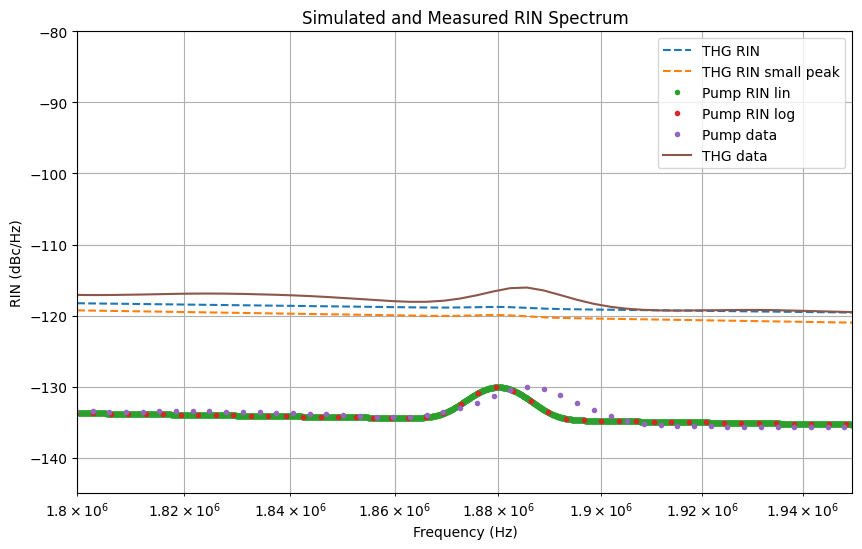

Integrated RIN value for pump: -31.06 dBc

Integrated RIN value for THG: -18.82 dBc
Difference is: 12.24 dB



NameError: name 'rin_spectrum_lin' is not defined

In [21]:
#Model for cascaded THG RIN data vs real RIN data

rin_spectrum_THG =model_RIN_spec(freqs_lin_fine, RIN_offset=10**(-95/10), RIN_offset_high_freq=10**(-125/10), decay_freq= 6e5, decay_factor=1.7e-6, decay_expo=5, first_rel_osc=[1e3,6e3,8e-6,3e3,0.5e3],second_rel_osc=[1e5,6e5,4e-4,5e5,0.3e5])
rin_spectrum_THG_small =model_RIN_spec(freqs_lin_fine, RIN_offset=10**(-95/10), decay_freq= 6e5, decay_factor=1.7e-6, decay_expo=5, first_rel_osc=[1e3,6e3,8e-6,3e3,0.5e3], second_rel_osc=[1e5,6e5,4e-5,5e5,0.3e5])


# Plot the RIN spectra
plt.figure(figsize=(10, 6))
plt.ylim([-145,-80])
plt.xlim([1e3,1e7])

plt.plot(freqs_lin_fine, 10 * np.log10(rin_spectrum_THG), label='THG RIN', linestyle='dashed')

plt.plot(freqs_lin_fine, 10 * np.log10(rin_spectrum_THG_small), label='THG RIN small peak', linestyle='dashed')

plt.plot(freqs_lin_fine, 10 * np.log10(rin_spectrum_lin_fine), '.', label='Pump RIN lin')

plt.plot(freqs_log, 10 * np.log10(rin_spectrum_log), '.', label='Pump RIN log')

plt.vlines(freqs_used[np.array(indices)-1],-140,-80)

plt.xscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('RIN (dBc/Hz)')
plt.title('Simulated and Measured RIN Spectrum')
plt.grid(True, which='both')


plt.plot(pump_data[:,0],(pump_data[:,1]),'.',label='Pump data')

plt.plot(THG_data[:,0],THG_data[:,1],label = 'THG data')

plt.xlim([18e5,1.95e6])
plt.legend()

plt.show()


#Calculate integrated values

print(f'Integrated RIN value for pump: {linear_to_dB(np.sum(rin_spectrum_lin_fine)*1e3):.2f} dBc\n')

print(f'Integrated RIN value for THG: {linear_to_dB(np.sum(rin_spectrum_THG)*1e3):.2f} dBc\nDifference is: {linear_to_dB(np.sum(rin_spectrum_THG)*1e3) - linear_to_dB(np.sum(rin_spectrum_lin_fine)*1e3):.2f} dB\n')

print(f'Integrated RIN value for THG with small rel. osc. freq. peak: {linear_to_dB(np.sum(rin_spectrum_THG_small)*1e3):.2f} dBc\nDifference is: {linear_to_dB(np.sum(rin_spectrum_THG_small)*1e3) - linear_to_dB(np.sum(rin_spectrum_lin)*1e3):.2f} dB')


In [ ]:
#Convert pump laser RIN PSD to time-domain

# Parameters
I_0 = 1                # Intensity offset (mean value) arbitrary units (should plug in real value)

sampling_interval = T/N 

N_freqs = len(freqs) 


magnitude = np.sqrt(rin_spectrum)/sampling_interval*np.sqrt(T) #Comes from:  PSD = lim(N--> inf) sampling_interval**2/Total_time * abs ( FFT(x(t)) )**2
                                                               # => abs( FFT(x(t)) ) * sqrt(PSD)*sqrt(T)/sampling_interval 
phase = 2*np.pi*np.random.randn(N_freqs) #Add random phase

FFT = magnitude * np.exp(1j*phase)


c:\Users\au617810\.conda\envs\conda_env\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\au617810\.conda\envs\conda_env\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, 'frequency (Hz)')

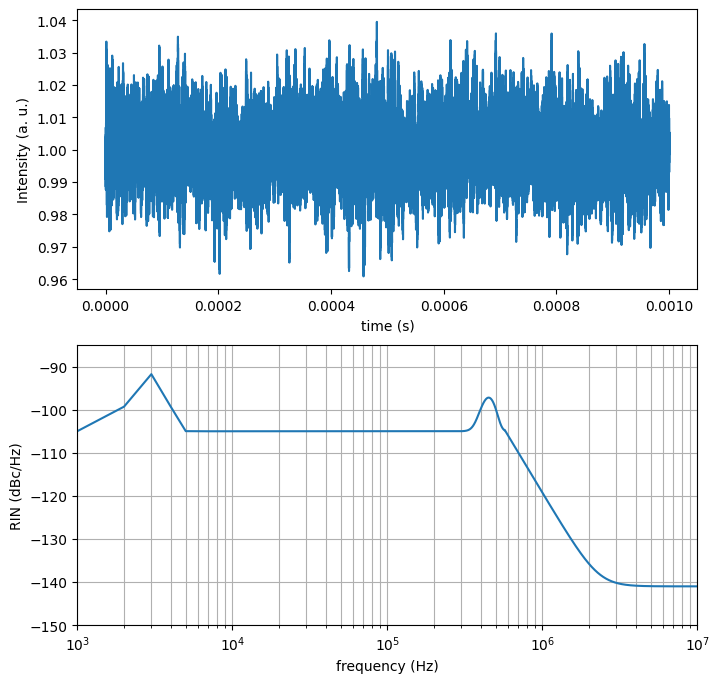

In [ ]:
#Plot time-domain signal and the corresponding RIN PSD

intensity = np.fft.ifft(FFT) + I_0
intensity_noise = intensity-np.mean(intensity)


fig = plt.figure(figsize=(8, 8))


ax1 = fig.add_subplot(211)
ax1.plot(np.linspace(0,T,len(intensity)),intensity)
ax1.set_ylabel('Intensity (a. u.)')
ax1.set_xlabel('time (s)')

ax2 = fig.add_subplot(212)
ax2.plot(freqs,10*np.log10(np.abs(np.fft.fft(intensity_noise)*sampling_interval/np.sqrt(T))**2)) # Going back to RIN PSD 
ax2.set_xscale('log')
ax2.set_xlim([1e3,1e7])
ax2.grid(True,'both')
ax2.set_ylim([-150,-85])
ax2.set_ylabel('RIN (dBc/Hz)')
ax2.set_xlabel('frequency (Hz)')


In [ ]:
#From intensity obtain second, fourth, and sixth order fluctuations. Finally, get deviations due to higher order terms in cascaded and direct THG

intensity =  np.abs(intensity)

avg_I = np.mean(intensity)

second_order = np.mean((intensity-avg_I)**2)

fourth_order = np.mean((intensity-avg_I)**4)

sixth_order = np.mean((intensity-avg_I)**6)

RIN = second_order/avg_I

# print(f'{ratio_to_dB(RIN,1):.1f}')

RIN_SFG_SHG = cascaded(RIN,fourth_order,sixth_order,avg_I)

print(f'Cascaded general expression derivation\nRatio = {RIN_SFG_SHG/RIN:.3f}',f'Deviation in percent from approximation: {RIN_SFG_SHG/RIN/9*100-100:.3f}\n ')

RIN_SFG_SHG_article = article_THG(RIN,fourth_order,sixth_order,avg_I)

print(f'direct THG article derivation\nRatio = {RIN_SFG_SHG_article/RIN:.3f}',f'Deviation in percent from approximation: {RIN_SFG_SHG_article/RIN/9*100-100:.3f}')

Cascaded general expression derivation
Ratio = 9.011 Deviation in percent from approximation: 0.127
 
direct THG article derivation
Ratio = 9.009 Deviation in percent from approximation: 0.104
